#### Steps Followed:
    1. Basic Cleaning - No Preprocessing
    2. Dataset Build 
    3. EDA & Visualization

In [1]:
#Packages
import os
import json
import re
import unicodedata
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Transcripts Cleaning
def clean_text_surgical(text):
    if not text: return ""
    
    #Unicode Removal
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    
    #Pattern-based cleaning
    noise_patterns = [
        #Common chatter found in transcripts
        r"good afternoon, and welcome to the.*Earnings Conference Call",
        r"at this time all participants will be in a listen-only mode",
        r"facilitating a question-and-answer session",
        r"this conference is being recorded for replay purposes",
        r"pardon me, this is the conference operator",
        r"i'd like to turn the call over to",
        r"please proceed", r"sir, you may begin", r"you may now disconnect",
        r"\[Operator Instructions\]",
        r"thank you\. (next|first) question (comes|is) from.*", 
        r"please limit yourselves to (one|a single) question.*",
        r"our first question today comes from.*",
        r"I will now turn the call back over to management.*",
        r"replaying the (webcast|call) will be available.*",
        r"has appears to have dropped\. Please remain on the line.*"
        r"can you hear (us|me)\?", 
        r"yes sir, we can hear you now"
    ]
    
    for pattern in noise_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    
    #Whitespace cleanup
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [3]:
#Processing
def process_transcripts(root_directory):
    all_turns = []
    root_path = Path(root_directory)
    
    for json_file in root_path.rglob('*.json'):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            meta = data.get('metadata', {})
            ticker = meta.get('ticker')
            date = meta.get('calendar_date')
            
            #Comparative Metric: Raw full transcript word count
            raw_full_text = data.get('transcript', {}).get('full_transcript_text', "")
            raw_total_words = len(raw_full_text.split())

            sections = data.get('transcript', {}).get('sections', [])
            for section in sections:
                s_type = section.get('section_type')
                
                for i, entry in enumerate(section.get('content', [])):
                    cleaned_text = clean_text_surgical(entry.get('text', ''))
                    word_count = len(cleaned_text.split())
                    
                    #Filter turns < 5 words (e.g., "Thank you", "Gary?")
                    if word_count < 5:
                        continue
                        
                    all_turns.append({
                        "ticker": ticker,
                        "fiscal_year": meta.get('fiscal_year'),
                        "fiscal_quarter": meta.get('fiscal_quarter'),
                        "calendar_date": date,
                        "company_name": meta.get('company_name'),
                        "sector": meta.get('sector'),
                        "section_type": s_type,
                        "speaker": entry.get('speaker'),
                        "role": entry.get('role'),
                        "turn_order": i + 1,
                        "text": cleaned_text,
                        "turn_word_count": word_count,
                        "transcript_total_words": raw_total_words
                    })
        except Exception as e:
            print(f"Error in {json_file}: {e}")

    #Granular DataFrame-Each row is a speaker role
    df_granular = pd.DataFrame(all_turns)
    
    if df_granular.empty:
        return pd.DataFrame(), pd.DataFrame()

    #Call-Level DataFrame-Each row is a full transcript per quarter 
    summary_rows = []
    for (ticker, date), group in df_granular.groupby(['ticker', 'calendar_date']):
        # Aggregate text by section type
        prep_text = " ".join(group[group['section_type'] == 'prepared_remarks']['text'])
        qa_text = " ".join(group[group['section_type'] == 'qa']['text'])
        
        #Captures metadata from first row of group
        first_row = group.iloc[0]
        
        summary_rows.append({
            "ticker": ticker,
            "calendar_date": date,
            "fiscal_year": first_row['fiscal_year'],
            "fiscal_quarter": first_row['fiscal_quarter'],
            "company_name": first_row['company_name'],
            "sector": first_row['sector'],
            "prepared_remarks_text": prep_text,
            "prep_remarks_word_count": len(prep_text.split()),
            "qa_text": qa_text,
            "qa_word_count": len(qa_text.split()),
            "full_transcript_word_count": first_row['transcript_total_words']
        })
        
    df_summary = pd.DataFrame(summary_rows)
    
    return df_granular, df_summary

In [4]:
#Execution
df_granular, df_summary = process_transcripts(r'C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\Normalized')

In [5]:
#Granular View
df_granular.head(3)

,ticker,fiscal_year,fiscal_quarter,calendar_date,company_name,sector,section_type,speaker,role,turn_order,text,turn_word_count,transcript_total_words
0,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Operator,moderator,1,"Good day, ladies and gentlemen and thank you f...",47,10399
1,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Abhey Lamba,executive,2,"Thanks, operator, and good afternoon. Thank yo...",233,10399
2,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Andrew Anagnost,executive,3,"Thanks, Abhey. We started off fiscal '20 with ...",213,10399


In [6]:
#Summary View
df_summary.head(5)

,ticker,calendar_date,fiscal_year,fiscal_quarter,company_name,sector,prepared_remarks_text,prep_remarks_word_count,qa_text,qa_word_count,full_transcript_word_count
0,ADSK,2019-05-23,2020,Q1,Autodesk Inc.,Information Technology,"Good day, ladies and gentlemen and thank you f...",3141,Our first question comes from the line of Phil...,7243,10399
1,ADSK,2019-08-27,2020,Q2,Autodesk Inc.,Information Technology,"Good day, ladies and gentlemen, and thank you ...",3469,"Thank you, sir. Our first question comes from ...",7323,10852
2,ADSK,2019-11-26,2020,Q3,Autodesk Inc.,Information Technology,"Ladies and gentlemen, thank you for standing b...",3440,Thank you. Our first question comes from Saket...,6594,10095
3,ADSK,2020-02-27,2020,Q4,Autodesk Inc.,Information Technology,"Ladies and gentlemen, thank you for standing b...",3553,Our first question comes from the line of Sake...,7212,10827
4,ADSK,2020-05-27,2021,Q1,Autodesk Inc.,Information Technology,"Ladies and gentlemen, thank you for standing b...",3582,Thank you. Our first question comes from Saket...,7935,11599


In [7]:
#Turn-level density across tickers for the granular dataset
print(df_granular["ticker"].value_counts())

DAL      2110
APA      1476
WMT      1360
GS       1309
APTV     1270
ADSK     1256
XOM      1138
BX       1115
INTC     1078
BKR       929
HPE       850
CMCSA     838
GOOGL     822
PYPL      736
FOX       564
Name: ticker, dtype: int64


DAL appears to have a higher interactivity compared to FOX

In [8]:
#Sections Count
print(df_granular["section_type"].value_counts())

qa                  14328
prepared_remarks     2523
Name: section_type, dtype: int64


The granular dataset exhibits a high degree of interactivity, with 14,609 turns occurring in the Q&A section compared to 2,553 in Prepared Remarks. This indicates that the Q&A session provides a significantly higher frequency of sentiment events for model training.

In [82]:
#Roles Count
print(df_granular["role"].value_counts())

executive    8093
analyst      5489
moderator    3580
Name: role, dtype: int64


The above demonstrates a healthy ratio of Executives to Analyst turns.

In [10]:
#Text variance
df_granular.groupby("section_type")["turn_word_count"].std().round(2)

section_type
prepared_remarks    684.34
qa                  116.22
Name: turn_word_count, dtype: float64

The lower variance in Q&A reflects the rhythmic nature of human dialogue ideal for granular turn-based sentiment classification. The higher variance in prepared remarks can be attributed to the long executive prepared texts.

In [11]:
#Full transcript count per ticker
print(df_summary["ticker"].value_counts())

ADSK     20
APA      20
APTV     20
BKR      20
CMCSA    20
DAL      20
GOOGL    20
GS       20
HPE      20
INTC     20
PYPL     20
XOM      20
BX       19
FOX      19
WMT      17
Name: ticker, dtype: int64


This showcases an almost equal no of transcripts per ticker for the study period. For a 5 year period, each company should ideally have 20 transcripts, which has been achieved for most of the tickers.

In [12]:
#Setting professional aesthetics
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

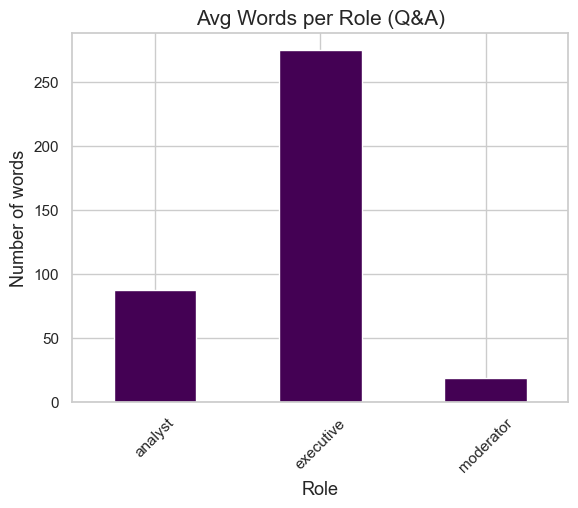

In [14]:
#Average Words per Role in Q&A
temp = df_granular.groupby("role")["turn_word_count"].mean()
temp.plot(kind="bar",stacked=False, colormap='viridis')
plt.title('Avg Words per Role (Q&A)')
plt.xlabel('Role')
plt.xticks(rotation=45)
plt.ylabel('Number of words')
plt.savefig('words_per_role.png', dpi=300)
plt.show()

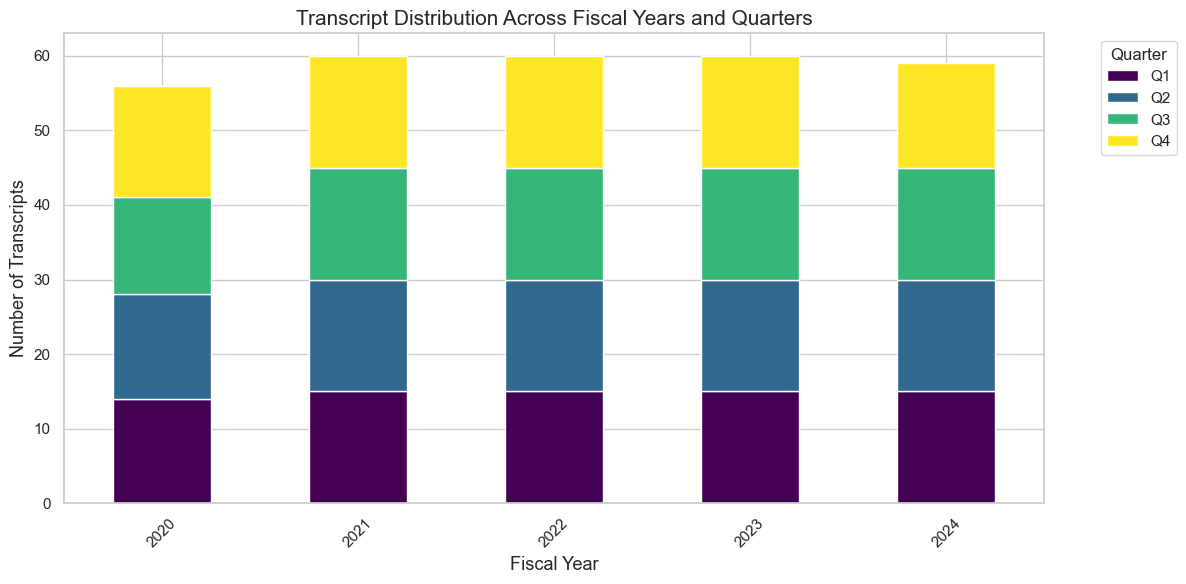

In [15]:
#Temporal Data Distribution
#Purpose:Check for dataset balance across time.
plt.figure(figsize=(12, 6))
temp_counts = df_summary.groupby(['fiscal_year', 'fiscal_quarter']).size().unstack(fill_value=0)
temp_counts.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')
plt.title('Transcript Distribution Across Fiscal Years and Quarters')
plt.xlabel('Fiscal Year')
plt.ylabel('Number of Transcripts')
plt.legend(title='Quarter', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('temporal_distribution.png', dpi=300)
plt.show()

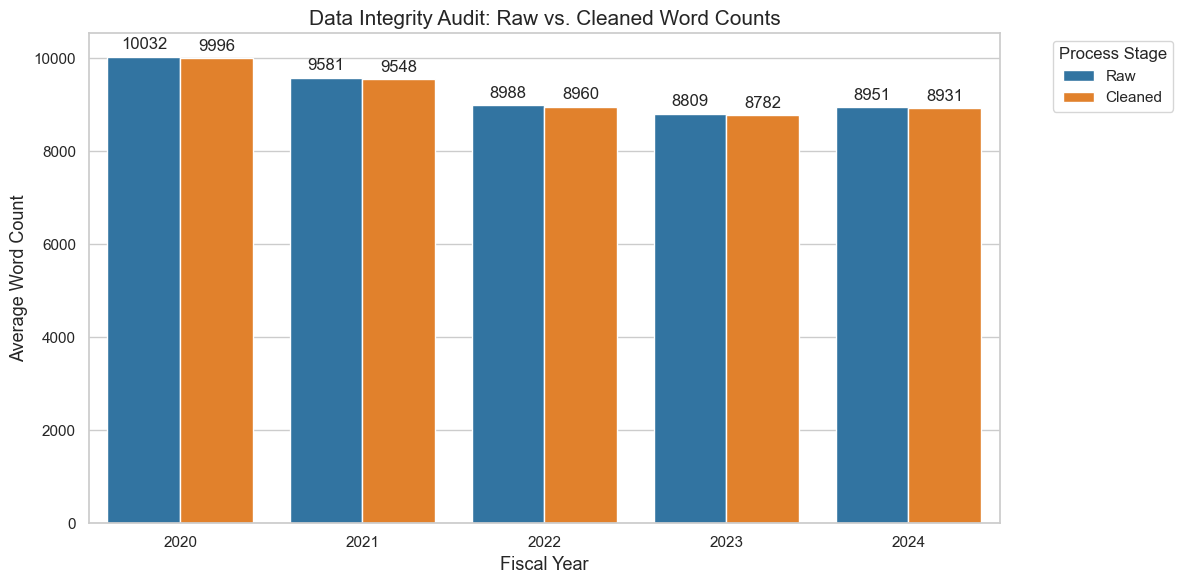

In [20]:
#Data Integrity Audit (Raw vs. Cleaned Word Counts)
#Purpose: Visualize the 'Information Loss' from cleaning logistical noise.
df_summary['total_cleaned_words'] = (
    df_summary['prep_remarks_word_count'] + df_summary['qa_word_count']
)
    
audit_data = df_summary.groupby('fiscal_year')[
    ['full_transcript_word_count', 'total_cleaned_words']
].mean().reset_index()
    
# Melting for seaborn barplot
audit_melted = audit_data.melt(
    id_vars='fiscal_year', 
    var_name='Type', 
    value_name='Avg Word Count'
)
# Rename for professional labels
audit_melted['Type'] = audit_melted['Type'].replace({
    'full_transcript_word_count': 'Raw', 'total_cleaned_words': 'Cleaned'
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='fiscal_year', y='Avg Word Count', hue='Type', data=audit_melted)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Data Integrity Audit: Raw vs. Cleaned Word Counts')
plt.ylabel('Average Word Count')
plt.xlabel('Fiscal Year')
plt.legend(title='Process Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('data_cleaning_audit.png', dpi=300)
plt.show()

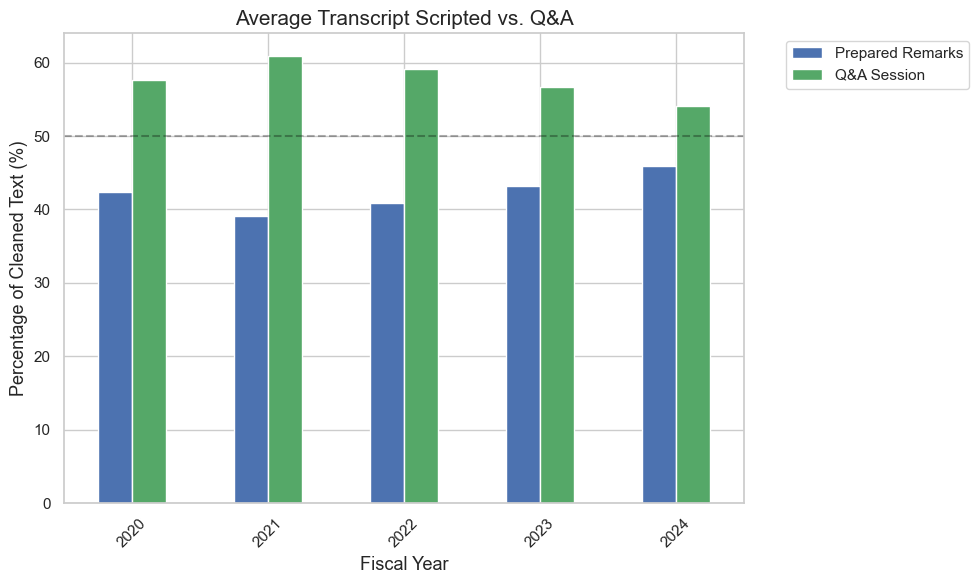

In [21]:
#Prepared Remarks vs. Q&A Volume Composition
#Purpose: Analyze the ratio of scripted vs. spontaneous communication.
df_summary['prep_pct'] = (df_summary['prep_remarks_word_count'] / df_summary['total_cleaned_words']) * 100
df_summary['qa_pct'] = (df_summary['qa_word_count'] / df_summary['total_cleaned_words']) * 100
    
comp_data = df_summary.groupby('fiscal_year')[['prep_pct', 'qa_pct']].mean()

plt.figure(figsize=(10, 6))
comp_data.plot(kind='bar', stacked=False, color=['#4c72b0', '#55a868'], ax=plt.gca())
plt.title('Average Transcript Scripted vs. Q&A')
plt.ylabel('Percentage of Cleaned Text (%)')
plt.xlabel('Fiscal Year')
plt.legend(['Prepared Remarks', 'Q&A Session'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(50, color='black', linestyle='--', alpha=0.3, label='50% Threshold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('transcript_composition.png', dpi=300)
plt.show()

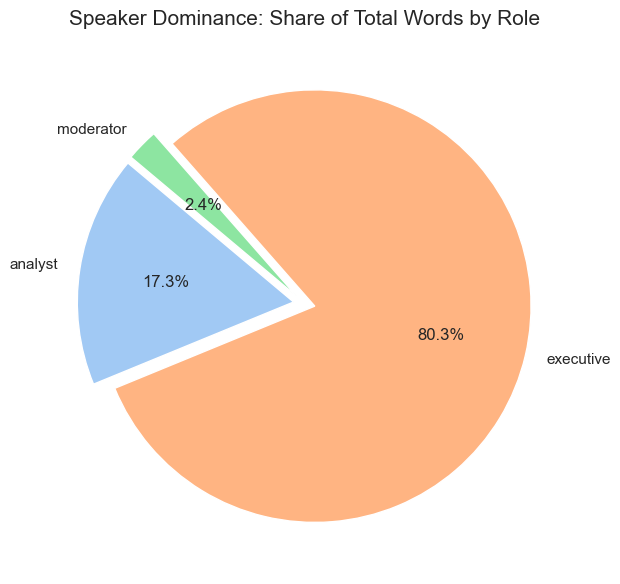

In [22]:
#Speaker Dominance
#Purpose: ShowS who dominates the conversation airtime.
plt.figure(figsize=(10, 6))
dominance = df_granular.groupby('role')['turn_word_count'].sum()
colors = sns.color_palette('pastel')[0:len(dominance)]
    
plt.pie(dominance, labels=dominance.index, autopct='%1.1f%%', 
         startangle=140, colors=colors, explode=[0.05]*len(dominance))
plt.title('Speaker Dominance: Share of Total Words by Role')
plt.tight_layout()
plt.savefig('speaker_dominance.png', dpi=300)
plt.show()

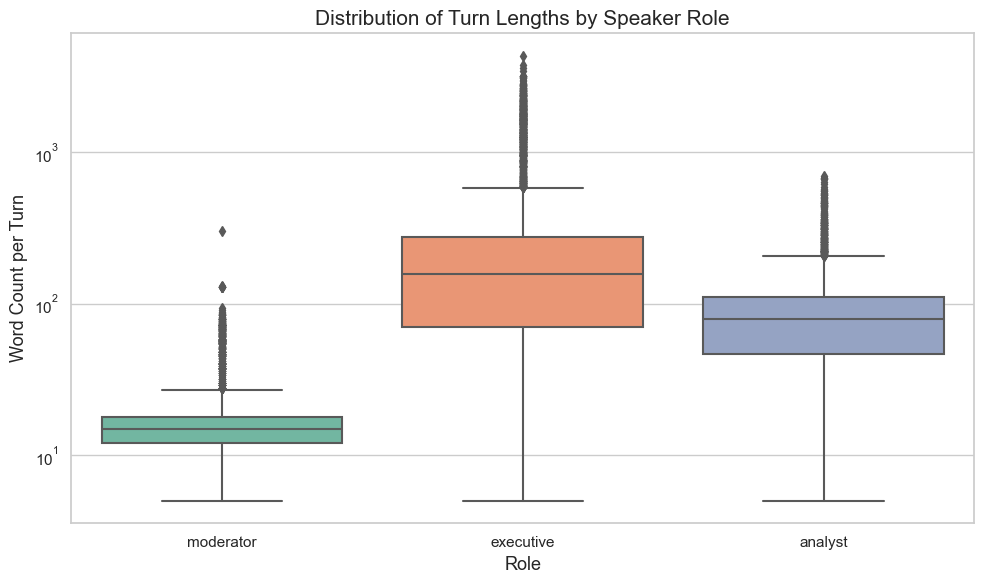

In [23]:
#Turn Length Distribution by Role
#Purpose: Proves that Executives own the narrative while Analysts probe.
plt.figure(figsize=(10, 6))
sns.boxplot(x='role', y='turn_word_count', data=df_granular, palette='Set2')
plt.yscale('log') # Essential because Executive remarks are 10x longer than Q&A turns
plt.title('Distribution of Turn Lengths by Speaker Role')
plt.ylabel('Word Count per Turn')
plt.xlabel('Role')
plt.tight_layout()
plt.show()

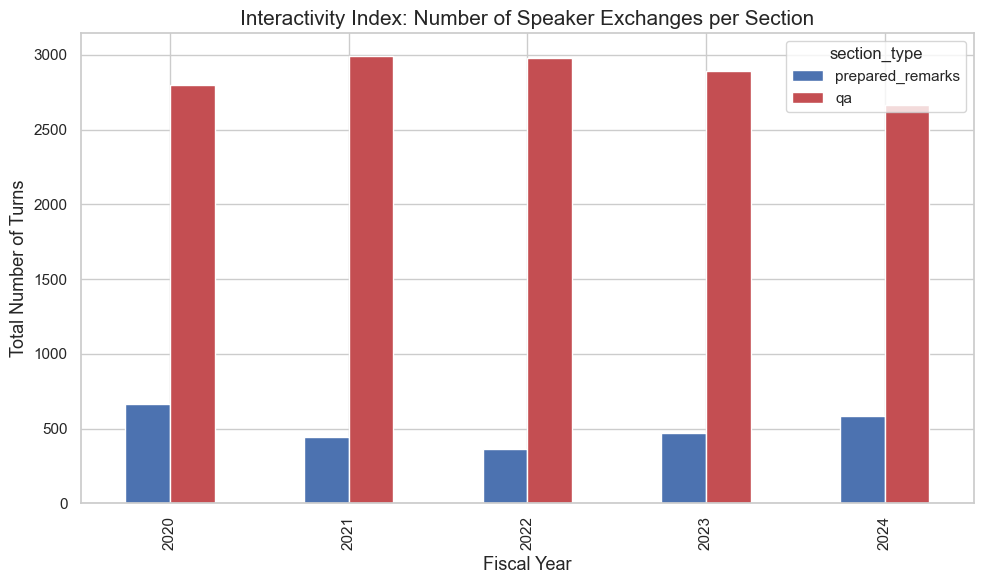

In [24]:
#Speaker Turn Frequency
#Purpose: How many times does a speaker interject
plt.figure(figsize=(10, 6))
turn_freq = df_granular.groupby(['fiscal_year', 'section_type']).size().unstack()
turn_freq.plot(kind='bar', ax=plt.gca(), color=['#4c72b0', '#c44e52'])
plt.title('Interactivity Index: Number of Speaker Exchanges per Section')
plt.ylabel('Total Number of Turns')
plt.xlabel('Fiscal Year')
plt.tight_layout()
plt.show()

A higher number of turns in Q&A as above suggests detailed debate between the analysts and executives.

In [26]:
#Summary Statistics Table
def generate_formal_thesis_table(df_granular, df_summary):
    """
    Creates a professionally structured table with grouped categories.
    """
    
    #Dataset Scale Metrics
    total_calls = df_summary.shape[0]
    total_turns = df_granular.shape[0]
    unique_tickers = df_summary['ticker'].nunique()
    
    #Cleaning Integrity Metrics
    avg_raw = df_summary['full_transcript_word_count'].mean()
    avg_clean = (df_summary['prep_remarks_word_count'] + df_summary['qa_word_count']).mean()
    retention = (avg_clean / avg_raw) * 100
    noise_removed = avg_raw - avg_clean
    
    #Sectional Texture Metrics
    avg_prep = df_summary['prep_remarks_word_count'].mean()
    avg_qa = df_summary['qa_word_count'].mean()

    #Structure
    table_data = [
        ["Dataset Scale", "Total Earnings Calls (N)", f"{total_calls}"],
        ["Dataset Scale", "Total Speaker Turns", f"{total_turns:,}"],
        ["Dataset Scale", "Unique Tickers (S&P 500)", f"{unique_tickers}"],
        ["Cleaning Integrity", "Avg. Information Retention (%)", f"{retention:.2f}%"],
        ["Cleaning Integrity", "Avg. Noise Removed per Call", f"{noise_removed:.0f}"],
        ["Sectional Texture", "Avg. Prepared Remarks Length", f"{avg_prep:.0f}"],
        ["Sectional Texture", "Avg. Q&A Session Length", f"{avg_qa:.0f}"]
    ]
    
    #DataFrame
    df_table = pd.DataFrame(table_data, columns=["Metric Category", "Feature", "Value"])
    df_table = df_table.set_index(["Metric Category", "Feature"])
    
    return df_table

# Execution
df_final_report = generate_formal_thesis_table(df_granular, df_summary)
print(df_final_report)

                                                    Value
Metric Category    Feature                               
Dataset Scale      Total Earnings Calls (N)           295
                   Total Speaker Turns             16,851
                   Unique Tickers (S&P 500)            15
Cleaning Integrity Avg. Information Retention (%)  99.69%
                   Avg. Noise Removed per Call         29
Sectional Texture  Avg. Prepared Remarks Length      3989
                   Avg. Q&A Session Length           5245
